In [1]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [2]:
import math

class Value:
    def __init__(self, data, _children =(), op='', label =''):
        self.data = data
        self._prev = set(_children)
        self._op = op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other
    

    def __pow__(self, other):
        if not isinstance(other, int):
            raise ValueError("Only integer powers at this time")

        out = Value(self.data ** other, (self, ), f'**{other}')
        def _backward():
            self.grad += (other * (self.data**(other -1))) * out.grad

        out._backward = _backward
        return out

    def __neg__(self):
        return self * (-1)


    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        if other.data == 0:
            raise ZeroDivisionError("Cannot divide by zero")

        return self * (other ** -1)

    def __rtruediv__(self, other):
        if self.data == 0:
            raise ZeroDivisionError("Cannot divide by zero")

        return other * (self ** -1)

    def __sub__(self, other):
        return self + (-other)


    def __rsub__(self, other):
        return other + (-self)


    def tanh(self):
        x = self.data
        t = (math.exp(x) - math.exp(-x)) / (math.exp(x) + math.exp(-x))
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out    

    def sigmoid(self):
        x = self.data
        s = math.exp(x) / ( 1 + math.exp(x))
        out = Value(s, (self, ), 'sigmoid')

        def _backward():
            self.grad += (s * (1 - s)) * out.grad

        out._backward = _backward
        return out

    def relu(self):
        leak = 0.001
        out = Value(self.data if self.data > 0 else leak, (self, ), 'relu')

        def _backward():
            derv = 1 if self.data > 0 else 0
            self.grad +=  derv * out.grad

        out._backward =_backward
        return out


    def backward(self):
        visited = set()
        topo = []
        def tsort(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    tsort(child)
                topo.append(v)

        tsort(self)

        self.grad = 1.0
        for n in reversed(topo):
            n._backward()

            

In [3]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

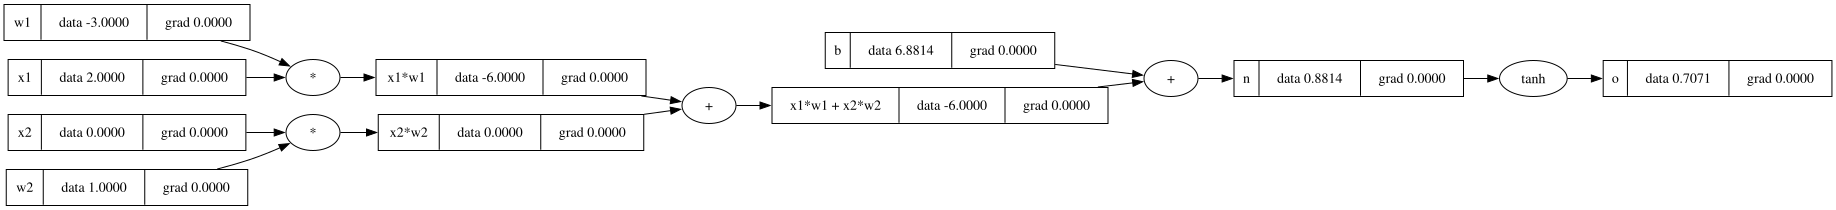

In [4]:
draw_dot(o)

In [5]:
import random

class Neuron:
    def __init__(self, nin):
        self.weights = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.bias = Value(random.uniform(-1, 1))

    def __call__(self, X):
        z = sum( wi*xi for xi, wi in zip(self.weights, X)) + self.bias
        ypred = z.tanh()
        return ypred

    def parameters(self):
        return self.weights + [self.bias]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, X):
        ypred = [ n(X) for n in self.neurons]
        return ypred[0] if len(ypred) == 1 else ypred

    def parameters(self):
        return [ p for n in self.neurons for p in n.parameters()]
            
        
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [ Layer(l1, l2) for l1, l2 in zip(sz, sz[1:]) ]
        # self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, X):
        for layer in self.layers:
            X = layer(X)
        return X
                
    def parameters(self):
        return [ p for l in self.layers for p in l.parameters()]

        

In [6]:
# model
nn = MLP(3, [4, 4, 1])

In [7]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [8]:
epochs = 9
learning_rate = 0.1

In [9]:
for epoch in range(epochs):
    ypred = [ nn(x) for x in xs]
    loss = sum((yt - yp)**2 for yt, yp in zip(ys, ypred))

    for p in nn.parameters():
        p.grad = 0.0
    loss.backward()

    for p in nn.parameters():
        p.data = p.data - learning_rate * p.grad
    
    print(f"epoch: {epoch} | loss: {loss}")

epoch: 0 | loss: Value(data=7.224131585534549)
epoch: 1 | loss: Value(data=5.447769123830339)
epoch: 2 | loss: Value(data=2.284496733993895)
epoch: 3 | loss: Value(data=5.819641054470781)
epoch: 4 | loss: Value(data=1.435972419281278)
epoch: 5 | loss: Value(data=0.08968929167598177)
epoch: 6 | loss: Value(data=0.049864223971340806)
epoch: 7 | loss: Value(data=0.03805185867832121)
epoch: 8 | loss: Value(data=0.03164239526830129)
